# Machine Learning - Decision Tree With Pokemon

## Import Libraries

In [1]:
## Begin Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
## End Imports

## Pokemon Dataset

<center><img src="../images/web/pokemon.webp"></center>

### Load Dataset

In [2]:
### Load Pokemon CSV
file = "../data/pokemon.csv"

pokemon = pd.read_csv(file, index_col=0)

### View Info

In [3]:
### View Info
pokemon.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 1 to 721
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        800 non-null    object
 1   Type 1      800 non-null    object
 2   Type 2      414 non-null    object
 3   Total       800 non-null    int64 
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 75.8+ KB


### Cleaning Data

In [4]:
## Fill Null Values with "None"
pokemon = pokemon.fillna("None")



### Preview First Few Rows

In [5]:
### Preview First Few Rows
pokemon.sample(5)



,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
#,,,,,,,,,,,,
255,Torchic,Fire,None,310,45,60,40,70,50,45,3,False
406,Budew,Grass,Poison,280,40,30,35,50,70,55,4,False
302,Sableye,Dark,Ghost,380,50,75,75,65,65,50,3,False
711,GourgeistAverage Size,Ghost,Grass,494,65,90,122,58,75,84,6,False
112,Rhydon,Ground,Rock,485,105,130,120,45,45,40,1,False


### Visualize Distribution of Data

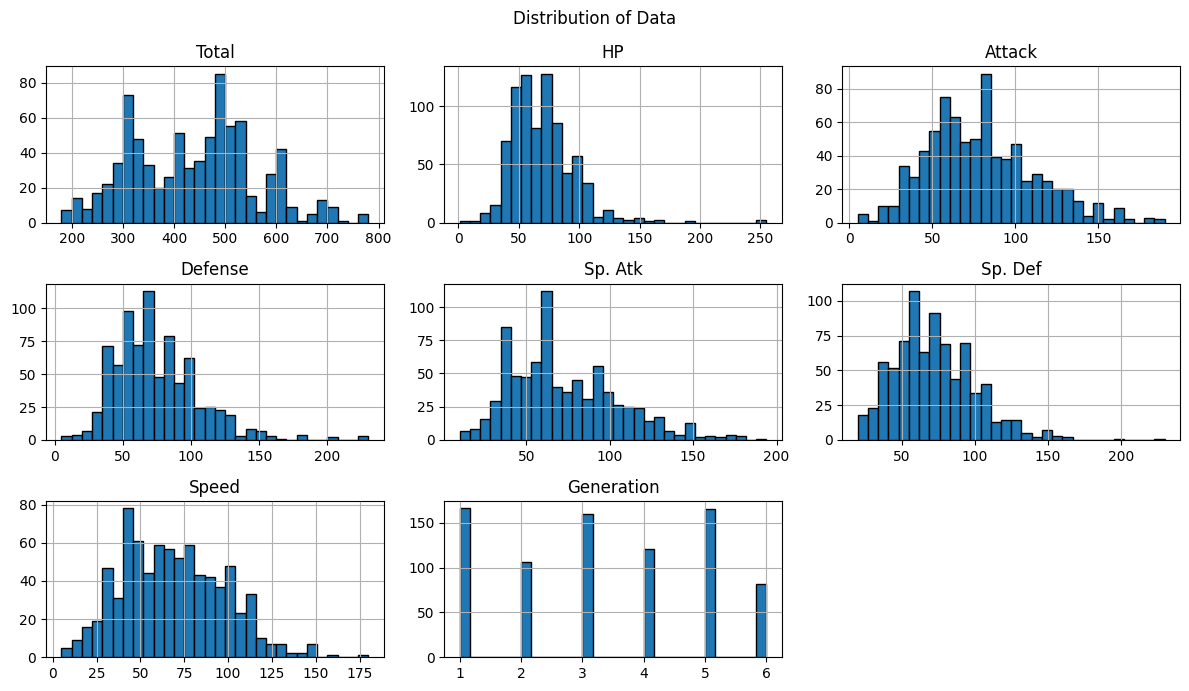

In [6]:
### Distribution of Data
pokemon.hist(figsize=(12,7),
             bins=30,
             edgecolor="black")

plt.subplots_adjust(hspace=0.7,
                    wspace=0.4)
plt.suptitle("Distribution of Data")
plt.tight_layout()

### Visualize Pokemon Type Count

#### Get Value Counts

__Syntax__:
```python
counts = dataframe[column_name].value_counts()
```

In [7]:
### Output Unique Types
pokemon_type_count = pokemon["Type 1"].value_counts()



#### Visualize Types as Bar Plot

__Syntax__:
```python
sns.barplot(x=x_value, y=y_value)
```

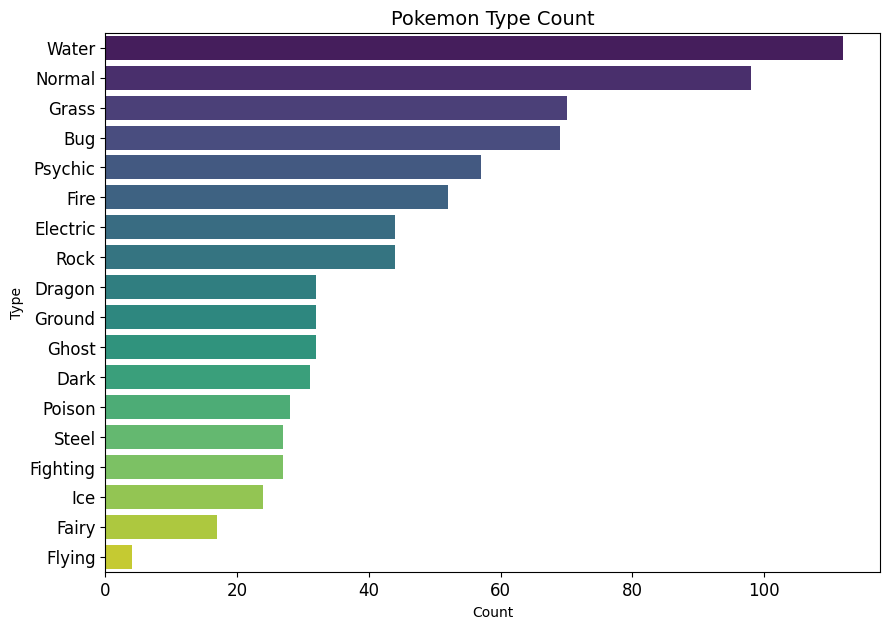

In [8]:
# Bar Plot
plt.figure(figsize=(10,7))

sns.barplot(x=pokemon_type_count.values, 
            y=pokemon_type_count.index, 
            palette='viridis', 
            hue=pokemon_type_count.index)

plt.title("Pokemon Type Count", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Type")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

### Prepare the Data

#### Define Features (`X`) and Target (`y`)

In [9]:
# Define Features and Target
features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Total', 'Legendary', 'Generation']
target = 'Type 1'

X = pokemon[features]
y = pokemon[target]




### Split up the Data

```python
train_test_split(X_data, y_data, test_size=split_value, random_state=seed_value)
```

In [10]:
# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=.2,
    random_state=42
)




### View X_train Info

In [11]:
# X_train Info
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 640 entries, 245 to 94
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   HP          640 non-null    int64
 1   Attack      640 non-null    int64
 2   Defense     640 non-null    int64
 3   Sp. Atk     640 non-null    int64
 4   Sp. Def     640 non-null    int64
 5   Speed       640 non-null    int64
 6   Total       640 non-null    int64
 7   Legendary   640 non-null    bool 
 8   Generation  640 non-null    int64
dtypes: bool(1), int64(8)
memory usage: 45.6 KB


### View y_train Info

In [12]:
# y_train Info
y_train.info()

<class 'pandas.core.series.Series'>
Index: 640 entries, 245 to 94
Series name: Type 1
Non-Null Count  Dtype 
--------------  ----- 
640 non-null    object
dtypes: object(1)
memory usage: 10.0+ KB


# Build Model - Decision Tree

### Build Model

```python
model = ModelType()
```

In [13]:
## Import and Build Decision Tree
clf = DecisionTreeClassifier(random_state=42)

### Train Model

__Syntax__:
```python
model.fit(x_training_data, y_training_data)
```

In [14]:
## Train Model
clf.fit(X_train, y_train)



,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Get Predictions

__Syntax:__
```python
predictions = clf.predict(test_data)
```

In [15]:
## Get Predictions
predictions = clf.predict(X_test)



### View Predictions vs Actual Data

In [16]:
### Create DataFrame of Predictions
predictionary = {
    "Actual Values": y_test,
    "Predictions": predictions
}

predictionary_df = pd.DataFrame(predictionary)

predictionary_df.sample(15, random_state=20)

,Actual Values,Predictions
#,,
530,Ground,Fire
306,Steel,Steel
49,Bug,Fire
330,Ground,Ice
456,Water,Water
34,Poison,Water
254,Grass,Ghost
302,Dark,Normal
336,Poison,Bug


### Evaluate Model

### Classification Report

Syntax:

```python
classification_report(Y_TEST, Y_PREDICTIONS)
```

In [17]:
### Classification Report Results
print(classification_report(y_test, predictions, zero_division=0))



              precision    recall  f1-score   support

         Bug       0.08      0.11      0.10         9
        Dark       0.11      0.14      0.12         7
      Dragon       0.12      0.25      0.17         4
    Electric       0.38      0.50      0.43        10
       Fairy       0.00      0.00      0.00         3
    Fighting       0.00      0.00      0.00         3
        Fire       0.00      0.00      0.00         7
      Flying       0.00      0.00      0.00         0
       Ghost       0.50      0.10      0.17        10
       Grass       0.14      0.17      0.15        18
      Ground       0.17      0.12      0.14         8
         Ice       0.00      0.00      0.00         3
      Normal       0.16      0.20      0.18        15
      Poison       0.00      0.00      0.00         8
     Psychic       0.40      0.25      0.31        16
        Rock       0.50      0.27      0.35        11
       Steel       0.17      0.25      0.20         4
       Water       0.22    

### Improve the Data

Focus on predicting one Pokémon type.

Create a new column called `Is_Electric` which contains `True` if the Pokémon is Electric and `False` is the Pokémon is not electric.

In [18]:
## Improve the Data - Electric vs Non-Electric
pokemon['Is_Electric'] = pokemon["Type 1"] == "Electric"



### Inspect Data

Get the Value Counts of the new columns.

In [19]:
# Value Counts
pokemon['Is_Electric'].value_counts()

Is_Electric
False    756
True      44
Name: count, dtype: int64

### Set Up Features and Target

In [20]:
# Set Up Features and Target Again
features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Total', 'Legendary', 'Generation']
target = 'Is_Electric'

X = pokemon[features]
y = pokemon[target]


### Set Up Training Data

In [21]:
# Set Up Training and Testing Data
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

### Set Up and Train Model

In [22]:
# Train Model
clf.fit(X_train, y_train)


# Get Predictions
predictions = clf.predict(X_test)



### Compare Actual Values vs Predicted Values

In [23]:
# Compare Predictions and Actual Values
predictionary = {
    "Actual_Values": y_test,
    "Predicted_Values": predictions
}

predictionary_df = pd.DataFrame(predictionary)

predictionary_df.sample(10, random_state=10)


,Actual_Values,Predicted_Values
#,,
18,False,False
75,False,False
536,False,False
329,False,False
580,False,False
583,False,False
595,False,False
60,False,False
183,False,False


### Model Evaluation

In [24]:
### Classification Report Results
print(classification_report(y_test, predictions))




              precision    recall  f1-score   support

       False       0.95      0.93      0.94       150
        True       0.23      0.30      0.26        10

    accuracy                           0.89       160
   macro avg       0.59      0.62      0.60       160
weighted avg       0.91      0.89      0.90       160



# Feature Importances

By accessing the model's feature importance, it may inform  us on which features are doing the heavy lifting in the model's predictions.
We would preserve those features, and possibily remove features that have relatively low importance.

Text(0, 0.5, 'Feature')

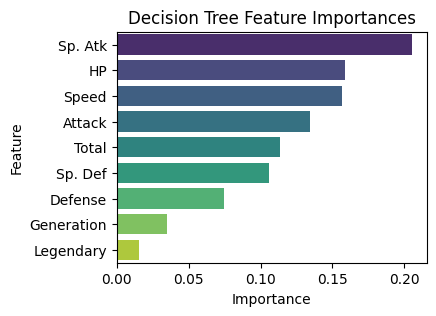

In [25]:
importances_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": clf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(4,3))

sns.barplot(
    data=importances_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis"
)

plt.title("Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

# Visualizing the Tree

By visualizing the tree, we can inspect the decision process selected by our model.

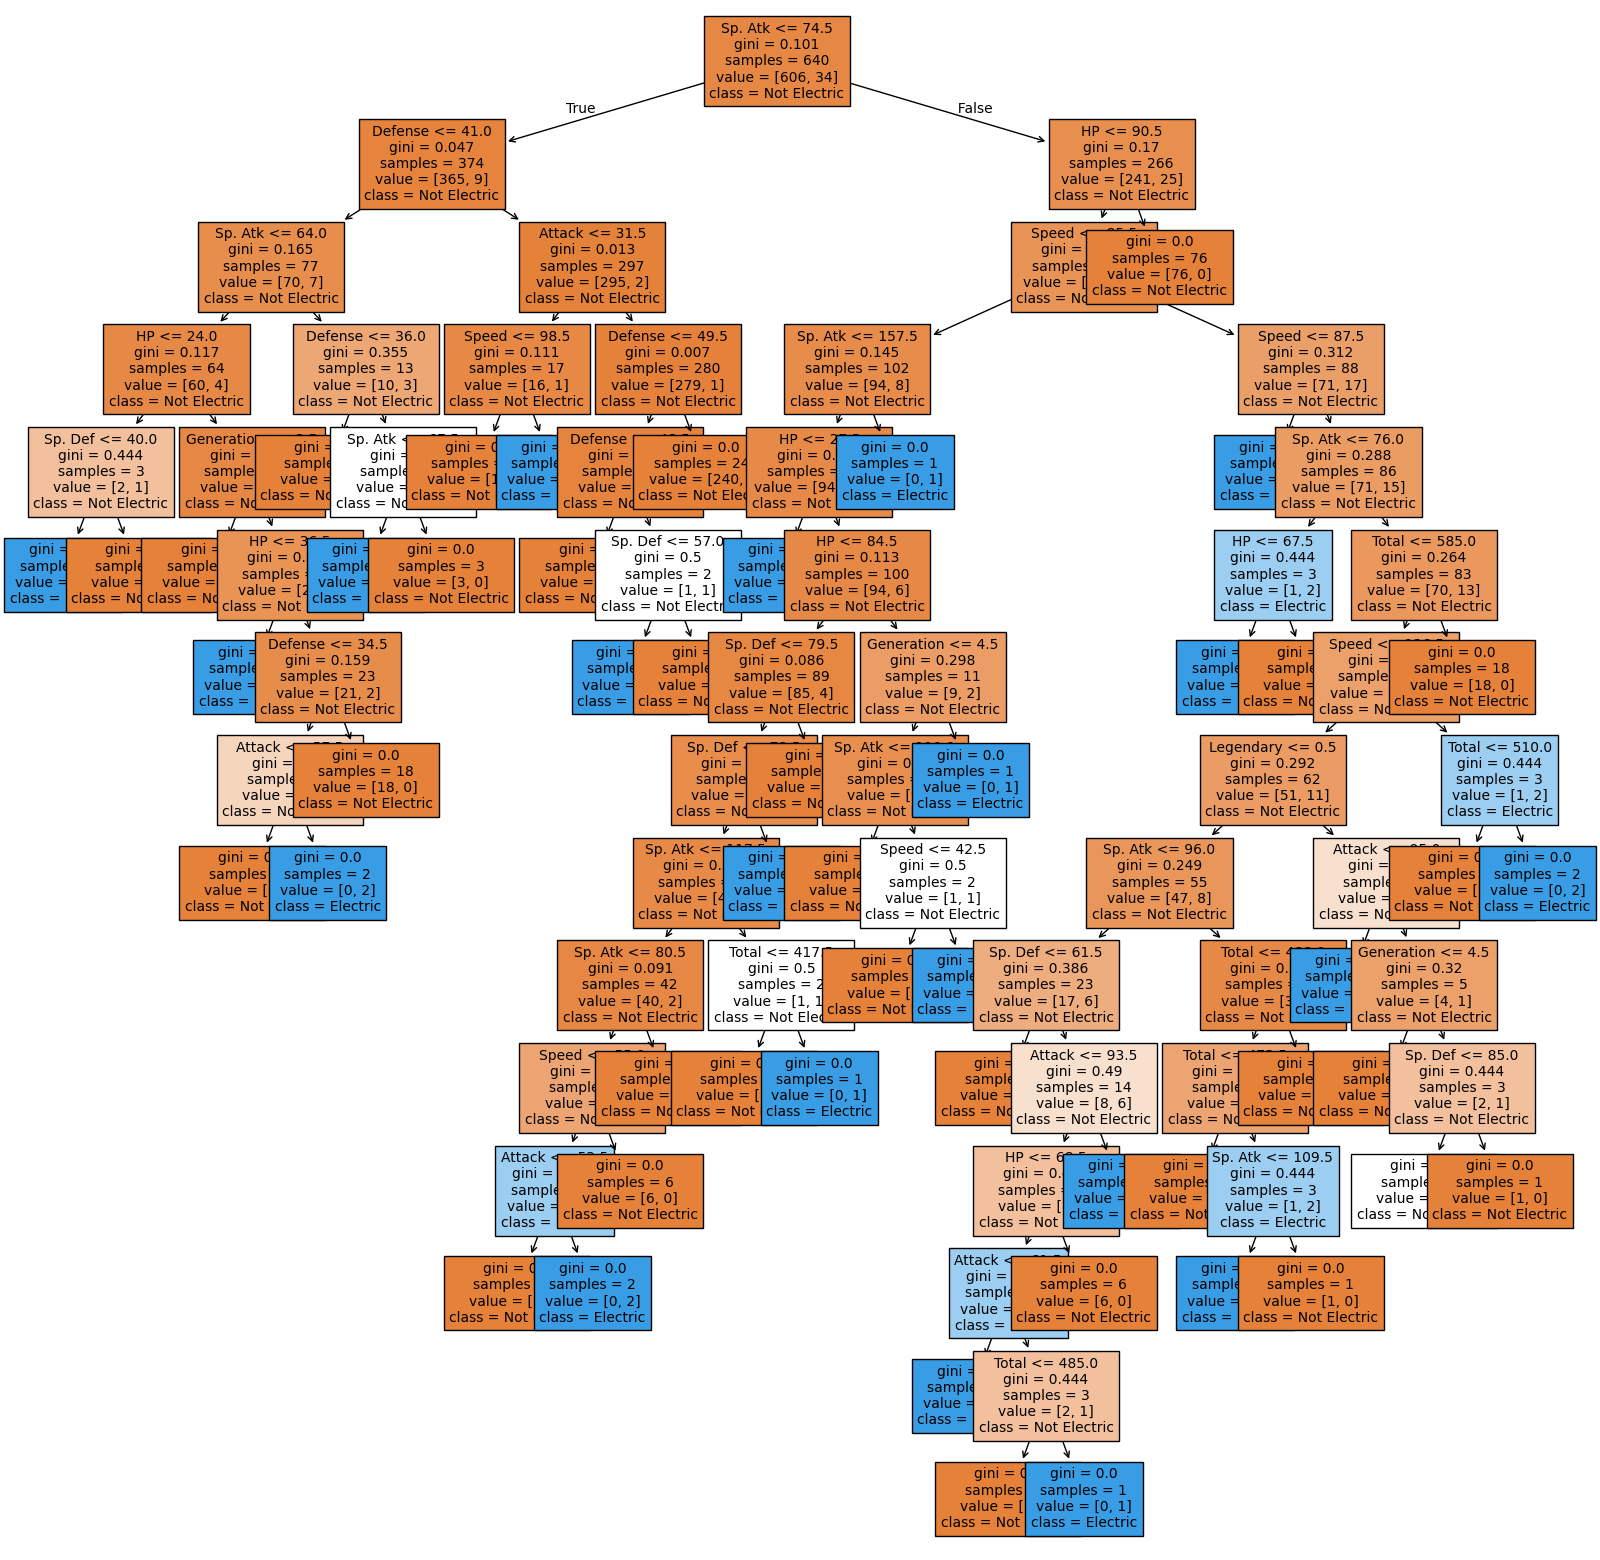

In [26]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,20))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=["Not Electric", "Electric"],
    filled=True,
    fontsize=10
)

plt.show()

# Trimming the Decision Tree

To reduce overhead, let's trim the features down to the top 3 based on importance.

Additionally, we will: 
* reduce the `maximum_depth` of the tree to `3` levels
* set it's `class_weight` `to balanced`
* train the model again with the updated features and parameter tuning.

In [27]:
# Select the Top 3 Features based on Importance
X = pokemon[importances_df["Feature"].head(3).values]

# Prepare the data for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=.2
)

# Tune the Tree's depth and class weight
clf_trimmed_top3 = DecisionTreeClassifier(
    max_depth=3,
    class_weight="balanced",
    random_state=42)

# Train the Model
clf_trimmed_top3.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


# Get New Predictions

Let's get new predictions for the modified tree in order to evaluate its performance.

In [28]:
# Get New Predictions
y_predict = clf_trimmed_top3.predict(X_test)

# Review the Model's Performance

Did the changes we make have any positive effects on the performance of our model?

In [29]:
print(classification_report(y_test, y_predict, zero_division=0))

              precision    recall  f1-score   support

       False       0.99      0.60      0.75       150
        True       0.13      0.90      0.23        10

    accuracy                           0.62       160
   macro avg       0.56      0.75      0.49       160
weighted avg       0.94      0.62      0.71       160



# Visualize the New Tree

What can we gather from the visual information?

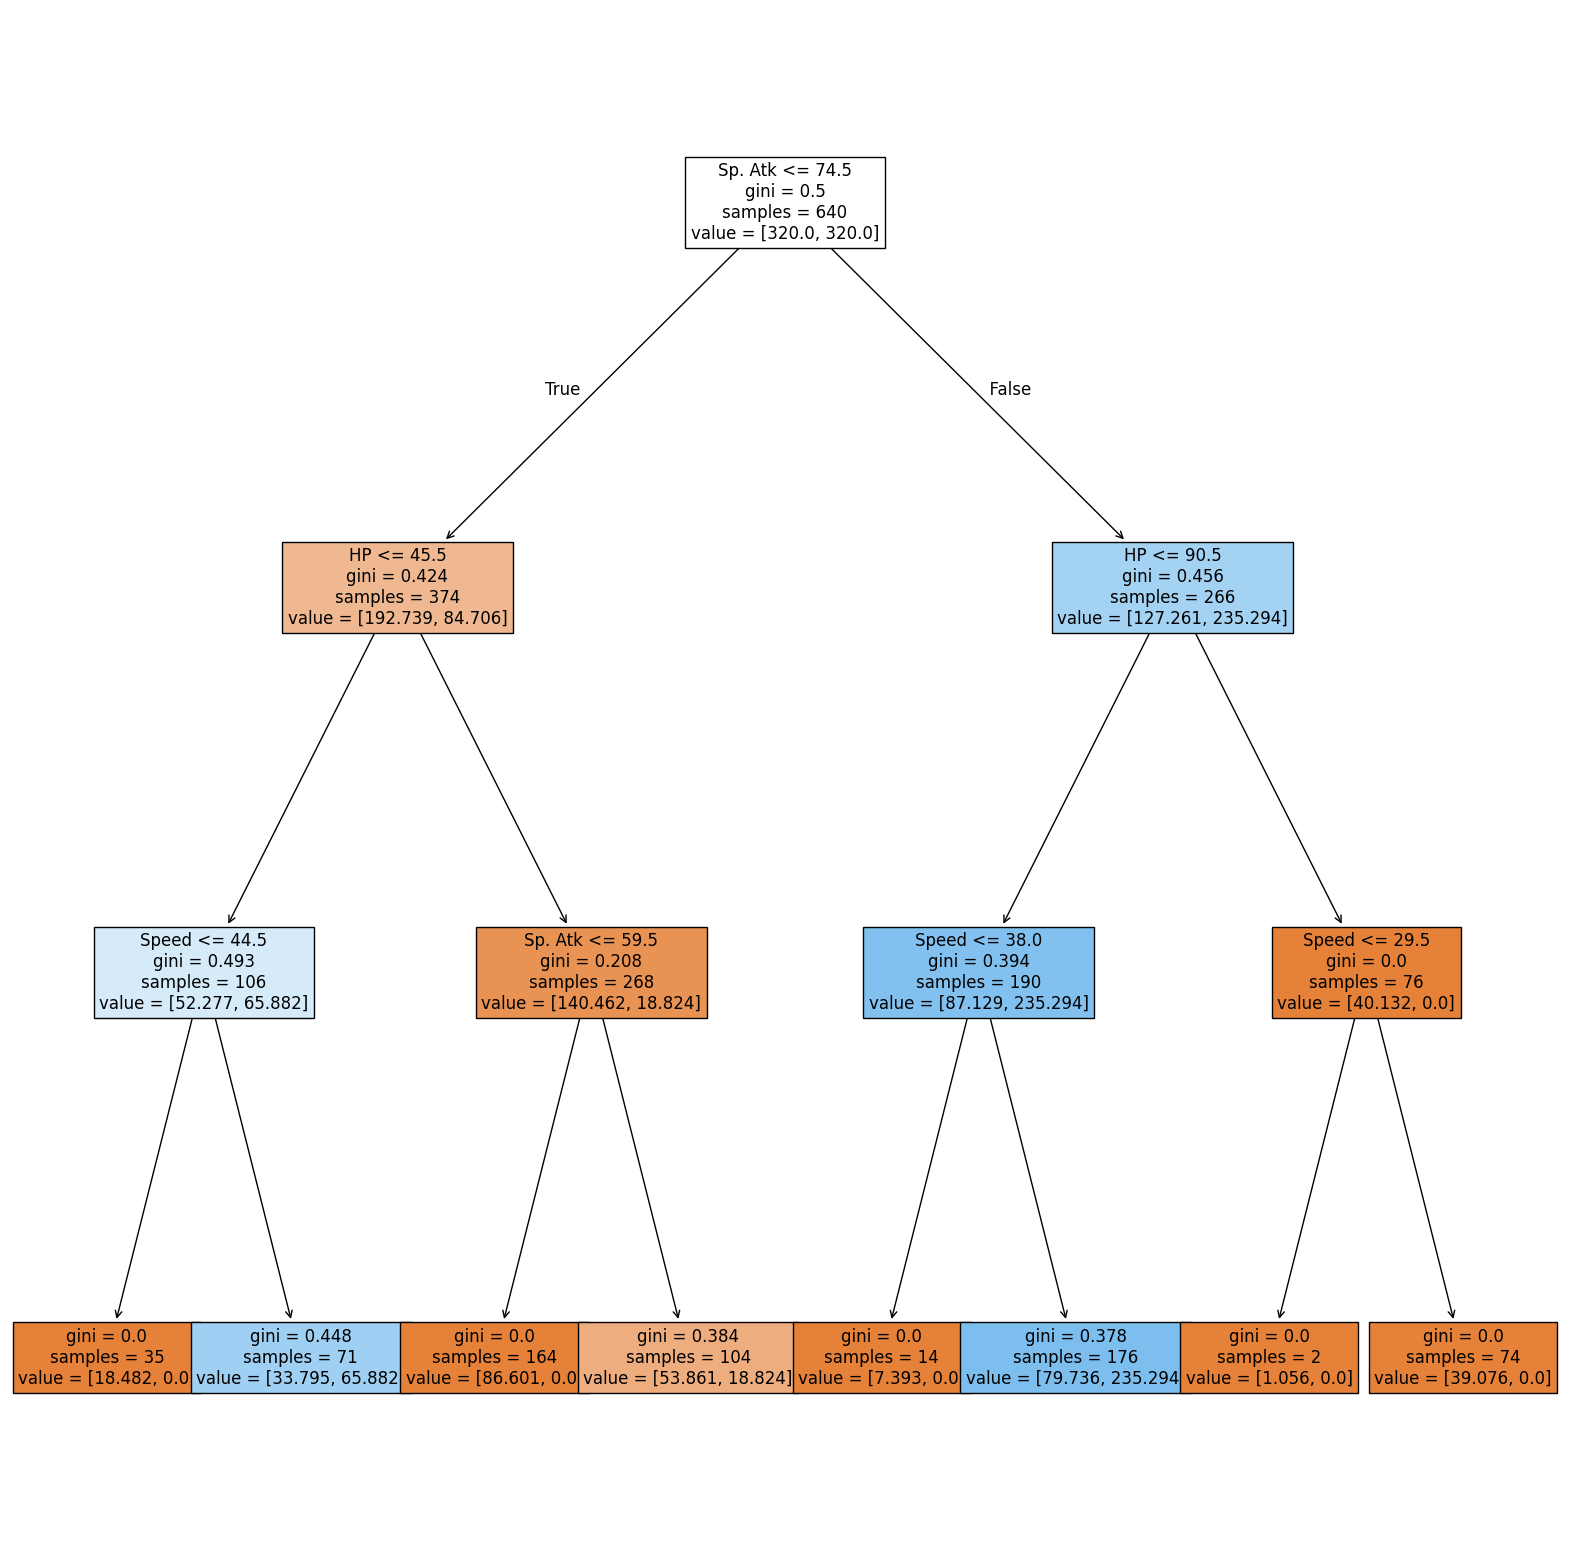

In [30]:
plt.figure(figsize=(20,20))

plot_tree(
    clf_trimmed_top3, 
    feature_names=X.columns,
    filled=True,
    fontsize=12
)

plt.show()